# ViT — comparing masking strategies

Builds on the player-strategy design from `vit_prototype.ipynb` and the masking-strategy abstraction from `resnet_test.ipynb` (`resnet-prototype` branch). Adds three pixel-space strategies (mean, zero, blur) alongside the original attention masking so all four can be evaluated on the same image with the same approximator and budget.


In [1]:
from __future__ import annotations

import math
from abc import ABC, abstractmethod

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor

import shapiq
from shapiq.imputer.base import Imputer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
class PlayerStrategy(ABC):
    @property
    @abstractmethod
    def n_players(self) -> int: ...

    @abstractmethod
    def grid_masks(self) -> torch.Tensor:
        """(n_players, gh, gw) bool — True on the tokens belonging to each player."""

    @abstractmethod
    def pixel_masks(self, image_size: int) -> torch.Tensor:
        """(n_players, H, W) bool — True on the pixels belonging to each player."""


class PatchStrategy(PlayerStrategy):
    def __init__(self, grid_size: int, n_players: int) -> None:
        side = int(math.sqrt(n_players))
        if side * side != n_players:
            raise ValueError("n_players must be a perfect square.")
        if grid_size % side != 0:
            raise ValueError("grid_size must be divisible by sqrt(n_players).")
        self.grid_size = grid_size
        self.side = side
        self.block = grid_size // side
        self._n_players = n_players

    @property
    def n_players(self) -> int:
        return self._n_players

    def grid_masks(self) -> torch.Tensor:
        masks = torch.zeros((self._n_players, self.grid_size, self.grid_size), dtype=torch.bool)
        for p in range(self._n_players):
            y = (p // self.side) * self.block
            x = (p % self.side) * self.block
            masks[p, y : y + self.block, x : x + self.block] = True
        return masks

    def pixel_masks(self, image_size: int) -> torch.Tensor:
        if image_size % self.grid_size != 0:
            raise ValueError("image_size must be divisible by grid_size.")
        scale = image_size // self.grid_size
        gm = self.grid_masks().numpy()
        pm = np.kron(gm, np.ones((scale, scale), dtype=bool))
        return torch.from_numpy(pm)


In [3]:
class MaskingStrategy(ABC):
    name: str = "abstract"

    @abstractmethod
    def predict_logits(
        self,
        model,
        pixel_values: torch.Tensor,    # (1, 3, H, W) on DEVICE
        grid_masks: torch.Tensor,      # (n_players, gh, gw)
        pixel_masks: torch.Tensor,     # (n_players, H, W)
        coalitions: torch.Tensor,      # (B, n_players)
    ) -> torch.Tensor: ...


def _absent_pixel_mask(coalitions: torch.Tensor, pixel_masks: torch.Tensor) -> torch.Tensor:
    absent = ~coalitions  # (B, N)
    return (absent[:, :, None, None] & pixel_masks[None, :, :, :]).any(dim=1)  # (B, H, W)


class AttentionMasking(MaskingStrategy):
    name = "attention"

    def predict_logits(self, model, pixel_values, grid_masks, pixel_masks, coalitions):
        b, n_players = coalitions.shape
        gh, gw = grid_masks.shape[-2:]
        token_grid = grid_masks.reshape(n_players, gh * gw)
        visible = (coalitions[:, :, None] & token_grid[None, :, :]).any(dim=1)  # (B, T)
        bool_masked_pos = ~visible
        batch = pixel_values.expand(b, -1, -1, -1)
        return model(pixel_values=batch, bool_masked_pos=bool_masked_pos).logits


class _PixelReplaceMasking(MaskingStrategy):
    def _replacement(self, pixel_values: torch.Tensor) -> torch.Tensor: ...

    def predict_logits(self, model, pixel_values, grid_masks, pixel_masks, coalitions):
        b = coalitions.shape[0]
        absent = _absent_pixel_mask(coalitions, pixel_masks)
        replacement = self._replacement(pixel_values).expand(b, -1, -1, -1)
        batch = pixel_values.expand(b, -1, -1, -1).clone()
        mask4d = absent.unsqueeze(1).expand_as(batch)
        batch = torch.where(mask4d, replacement, batch)
        return model(pixel_values=batch).logits


class MeanColorMasking(_PixelReplaceMasking):
    name = "mean"
    def _replacement(self, pixel_values: torch.Tensor) -> torch.Tensor:
        return pixel_values.mean(dim=(2, 3), keepdim=True).expand_as(pixel_values)


class ZeroMasking(_PixelReplaceMasking):
    name = "zero"
    def _replacement(self, pixel_values: torch.Tensor) -> torch.Tensor:
        return torch.zeros_like(pixel_values)


class BlurMasking(MaskingStrategy):
    name = "blur"

    def __init__(self, kernel_size: int = 31, sigma: float = 8.0) -> None:
        if kernel_size % 2 == 0:
            kernel_size += 1
        self.kernel_size = kernel_size
        self.sigma = sigma
        self._blurred_cache: torch.Tensor | None = None

    def _blurred(self, pixel_values: torch.Tensor) -> torch.Tensor:
        if self._blurred_cache is None:
            import torch.nn.functional as F  # noqa: N812
            k = self.kernel_size
            ax = torch.arange(k, device=pixel_values.device) - (k - 1) / 2.0
            xx, yy = torch.meshgrid(ax, ax, indexing="ij")
            kernel = torch.exp(-(xx**2 + yy**2) / (2.0 * self.sigma**2))
            kernel = (kernel / kernel.sum()).to(pixel_values.dtype)
            kernel = kernel.expand(3, 1, k, k)
            self._blurred_cache = F.conv2d(pixel_values, kernel, padding=k // 2, groups=3)
        return self._blurred_cache

    def predict_logits(self, model, pixel_values, grid_masks, pixel_masks, coalitions):
        b = coalitions.shape[0]
        absent = _absent_pixel_mask(coalitions, pixel_masks)
        blurred = self._blurred(pixel_values).expand(b, -1, -1, -1)
        batch = pixel_values.expand(b, -1, -1, -1).clone()
        mask4d = absent.unsqueeze(1).expand_as(batch)
        batch = torch.where(mask4d, blurred, batch)
        return model(pixel_values=batch).logits


In [4]:
class ViTImputer(Imputer):
    def __init__(
        self,
        model,
        pixel_values: torch.Tensor,
        player_strategy: PlayerStrategy,
        masking_strategy: MaskingStrategy,
        class_id: int,
        image_size: int,
        normalize: bool = True,
        batch_size: int = 32,
    ) -> None:
        dummy_data = np.zeros((1, player_strategy.n_players))
        super().__init__(model=model, data=dummy_data)
        self.pixel_values = pixel_values
        self.player_strategy = player_strategy
        self.masking_strategy = masking_strategy
        self.class_id = class_id
        self.batch_size = batch_size

        # cache the player masks once
        self._grid_masks = player_strategy.grid_masks().to(pixel_values.device)
        self._pixel_masks = player_strategy.pixel_masks(image_size).to(pixel_values.device)

        self.empty_prediction = float(
            self.value_function(np.zeros((1, self.n_players), dtype=bool))[0]
        )
        if normalize:
            self.normalization_value = self.empty_prediction

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        if coalitions.ndim == 1:
            coalitions = coalitions.reshape(1, -1)
        coals_t = torch.as_tensor(coalitions, dtype=torch.bool, device=self.pixel_values.device)
        outs: list[torch.Tensor] = []
        with torch.no_grad():
            for start in range(0, coals_t.shape[0], self.batch_size):
                chunk = coals_t[start : start + self.batch_size]
                logits = self.masking_strategy.predict_logits(
                    self.model, self.pixel_values,
                    self._grid_masks, self._pixel_masks, chunk,
                )
                probs = torch.softmax(logits, dim=-1)
                outs.append(probs[:, self.class_id])
        return torch.cat(outs).cpu().numpy()


In [5]:
image = Image.open("dog.png").convert("RGB")
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch32-384")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch32-384").to(DEVICE)
model.eval()

model.vit.embeddings.mask_token = torch.nn.Parameter(
    torch.zeros(1, 1, model.config.hidden_size, device=DEVICE)
)

inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(DEVICE)

with torch.no_grad():
    logits = model(pixel_values=pixel_values).logits
class_id = int(logits.argmax(-1).item())
class_name = model.config.id2label[class_id]
prob = float(torch.softmax(logits, dim=-1)[0, class_id])
print(f"Predicted class: {class_id} ({class_name}) with p={prob:.3f}")


Predicted class: 207 (golden retriever) with p=0.981


### Patch layout

Legend for the bar chart below — these are the `Patch i` indices.


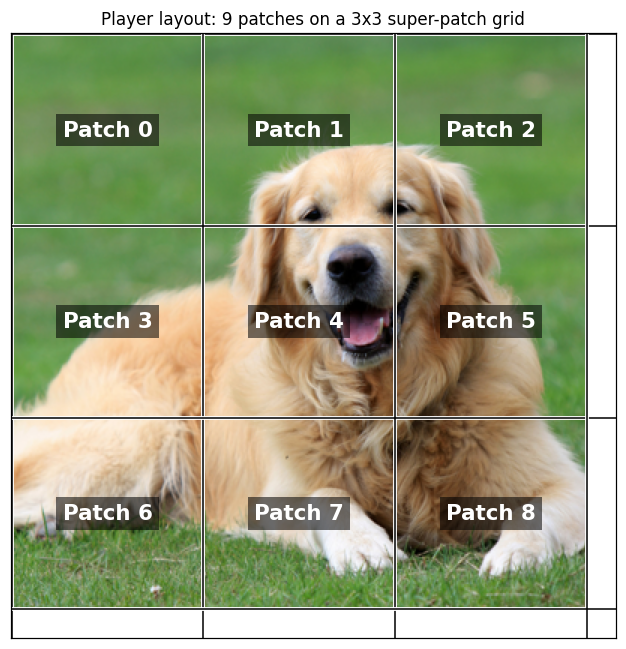

In [6]:
IMAGE_SIZE = model.config.image_size
PATCH_SIZE = model.config.patch_size
GRID_SIZE = IMAGE_SIZE // PATCH_SIZE

strategy = PatchStrategy(grid_size=GRID_SIZE, n_players=9)
image_resized = image.resize((IMAGE_SIZE, IMAGE_SIZE))
side, block_px = strategy.side, strategy.block * PATCH_SIZE

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_resized)
for i in range(side + 1):
    pos = i * block_px
    ax.axhline(pos, color="white", linewidth=2.5)
    ax.axvline(pos, color="white", linewidth=2.5)
    ax.axhline(pos, color="black", linewidth=1.0)
    ax.axvline(pos, color="black", linewidth=1.0)
for p in range(strategy.n_players):
    row, col = divmod(p, side)
    cx = col * block_px + block_px // 2
    cy = row * block_px + block_px // 2
    ax.text(cx, cy, f"Patch {p}", ha="center", va="center",
            fontsize=14, fontweight="bold", color="white",
            bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=4))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Player layout: {strategy.n_players} patches on a {side}x{side} super-patch grid",
             fontsize=11)
plt.tight_layout()
plt.show()


### Run all four strategies

Same approximator (k-SII, max_order=2), same budget (128). Only the masking strategy changes.


In [7]:
STRATEGIES: dict[str, MaskingStrategy] = {
    "attention": AttentionMasking(),
    "mean":      MeanColorMasking(),
    "zero":      ZeroMasking(),
    "blur":      BlurMasking(kernel_size=31, sigma=8.0),
}

BUDGET = 128
RNG = 0

interaction_values: dict[str, shapiq.InteractionValues] = {}
empty_predictions: dict[str, float] = {}

for name, masking in STRATEGIES.items():
    imputer = ViTImputer(
        model=model, pixel_values=pixel_values,
        player_strategy=strategy, masking_strategy=masking,
        class_id=class_id, image_size=IMAGE_SIZE, batch_size=32,
    )
    approx = shapiq.SHAPIQ(n=imputer.n_players, max_order=2, index="k-SII", random_state=RNG)
    iv = approx.approximate(budget=BUDGET, game=imputer)
    interaction_values[name] = iv
    empty_predictions[name] = imputer.empty_prediction
    print(f"[{name:9s}] empty pred = {imputer.empty_prediction:.4f}   "
          f"top-1 SV = {iv.get_n_order_values(1).max():+.4f}")


[attention] empty pred = 0.0002   top-1 SV = +0.6383
[mean     ] empty pred = 0.0011   top-1 SV = +0.7343
[zero     ] empty pred = 0.0006   top-1 SV = +0.7511
[blur     ] empty pred = 0.9600   top-1 SV = +0.0253


### Heatmaps

First-order Shapley values painted on the image, independent color scale per panel.


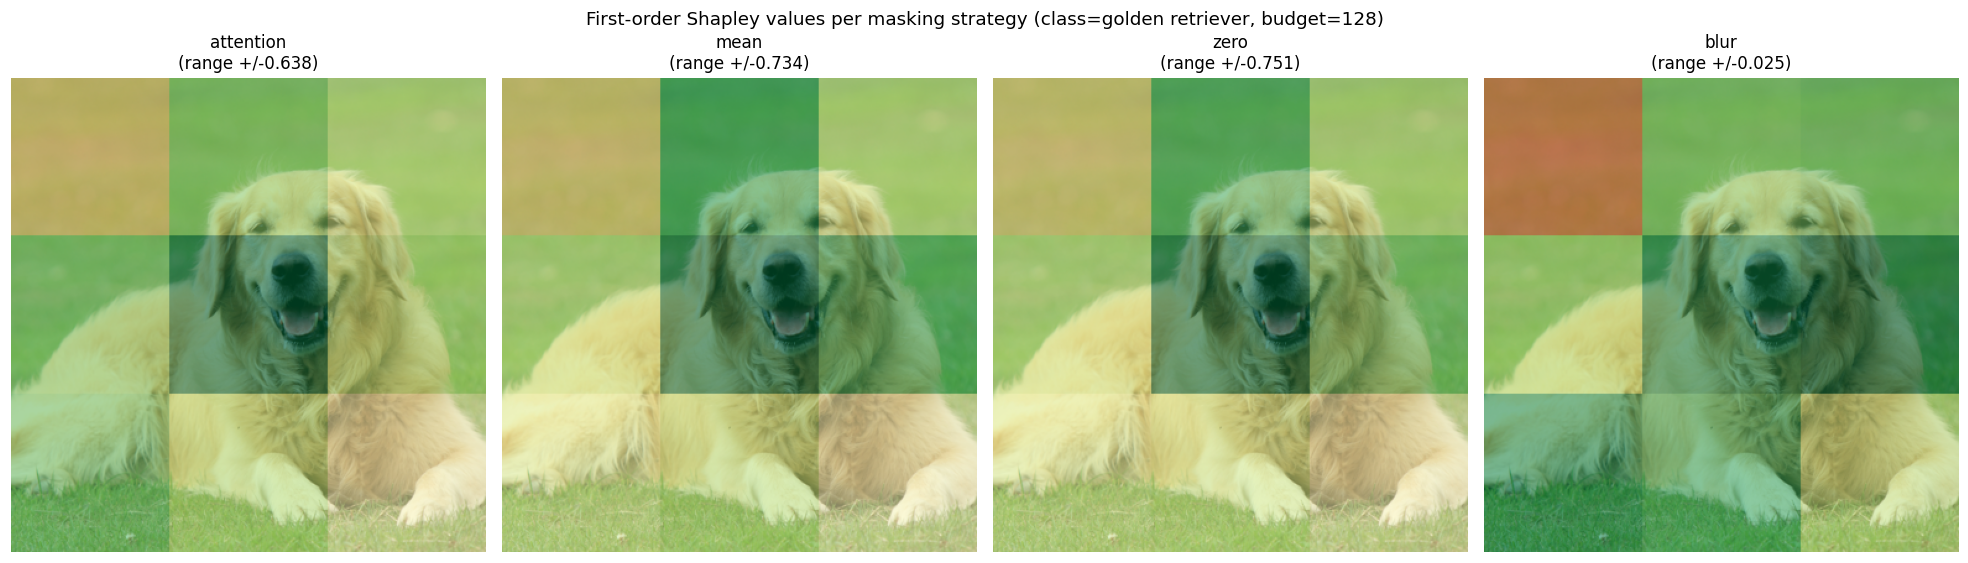

In [8]:
def patch_heatmap(first_order: np.ndarray) -> np.ndarray:
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=float)
    side = strategy.side
    block = strategy.block
    for p in range(strategy.n_players):
        y = (p // side) * block
        x = (p % side) * block
        grid[y : y + block, x : x + block] = first_order[p]
    return np.kron(grid, np.ones((PATCH_SIZE, PATCH_SIZE)))


fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, iv) in zip(axes, interaction_values.items()):
    fo = iv.get_n_order_values(1)
    heat = patch_heatmap(fo)
    vmax = max(abs(heat.min()), abs(heat.max())) or 1.0
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    ax.imshow(image_resized)
    ax.imshow(heat, alpha=0.55, cmap=cm.RdYlGn, norm=norm)
    ax.set_title(f"{name}\n(range +/-{vmax:.3f})", fontsize=11)
    ax.axis("off")
plt.suptitle(f"First-order Shapley values per masking strategy "
             f"(class={class_name}, budget={BUDGET})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Per-patch comparison

Same data on a shared y-axis — magnitudes are directly comparable here.


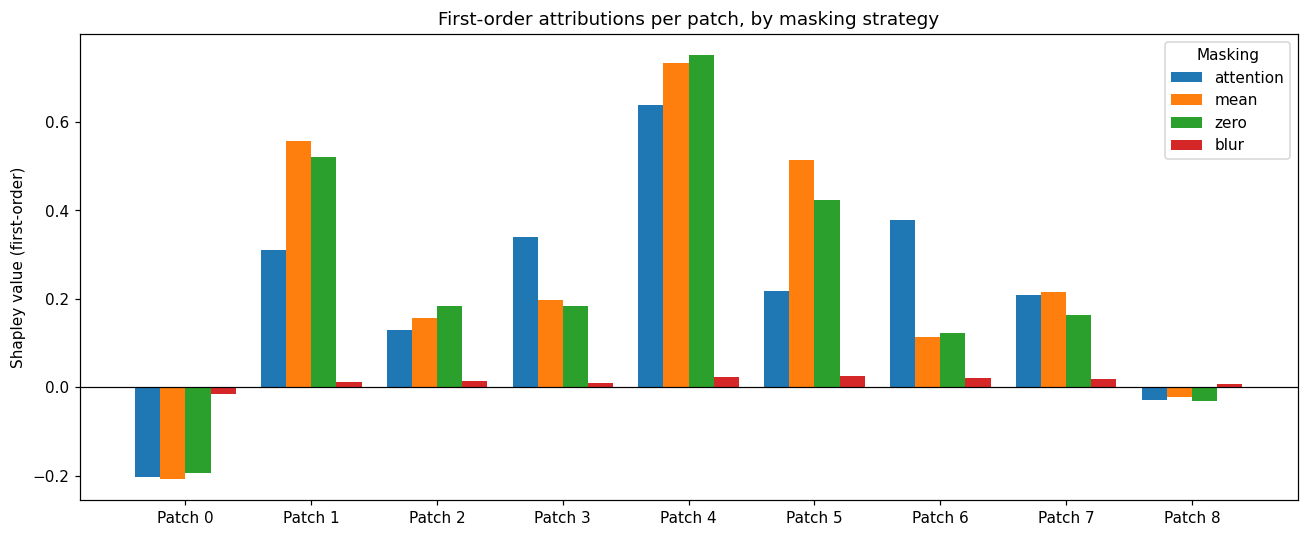

In [9]:
names = list(interaction_values.keys())
fo_matrix = np.stack([interaction_values[n].get_n_order_values(1) for n in names])

x = np.arange(strategy.n_players)
width = 0.2
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, n in enumerate(names):
    ax.bar(x + (i - 1.5) * width, fo_matrix[i], width, label=n, color=colors[i])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"Patch {i}" for i in range(strategy.n_players)])
ax.set_ylabel("Shapley value (first-order)")
ax.set_title("First-order attributions per patch, by masking strategy")
ax.legend(title="Masking")
plt.tight_layout()
plt.show()


### Cross-strategy correlation

Pearson asks whether two strategies put the same numerical values on the same patches; Spearman asks whether they rank patches the same way. High Spearman with low Pearson = same ranking, different magnitudes.


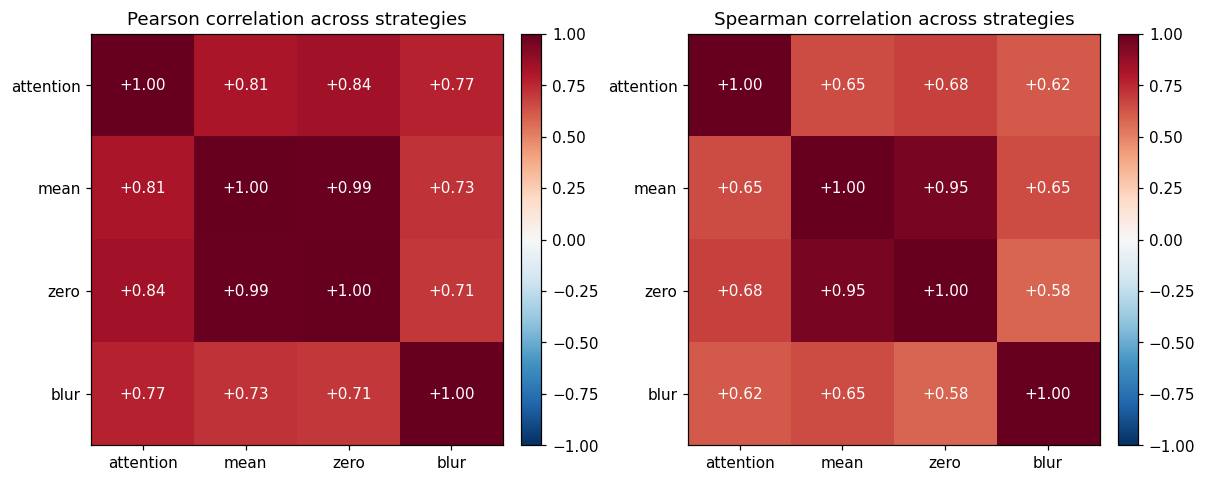

In [10]:
from scipy.stats import spearmanr  # noqa: E402

pearson = np.corrcoef(fo_matrix)
spearman = np.zeros_like(pearson)
for i in range(len(names)):
    for j in range(len(names)):
        spearman[i, j] = spearmanr(fo_matrix[i], fo_matrix[j]).correlation

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(names)), names)
    ax.set_yticks(range(len(names)), names)
    ax.set_title(f"{title} correlation across strategies")
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{mat[i, j]:+.2f}", ha="center", va="center",
                    color="white" if abs(mat[i, j]) > 0.5 else "black", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


### Findings

Attention is the most reliable of the four. Zero and mean inflate magnitudes by ~15-20% because the masked image is OOD and the model panics — pattern is right, scale isn't. Mean and zero are nearly the same operation in normalized pixel space (+0.99 Pearson), so running both is redundant.

Blur with kernel=31, sigma=8 didn't actually hide the dog — empty prediction stayed at 0.96, so there was no probability budget to distribute and every Shapley value collapsed to ~0. Stronger blur (sigma > 30, or repeated passes) would behave more like attention.

Attention is the only strategy where the masked patch is genuinely absent from the model's input. The mask token is consumed by the transformer as the architecture is designed to handle it (BEiT/MAE pretraining), so the prediction reflects missing info rather than corrupted input.

Sanity check before trusting any explanation: print the empty prediction. If it's not much lower than the original, the masking isn't doing anything and the attributions are noise. Would have flagged the blur problem above without needing any of the comparison plots.

Defaults: attention for ViT, blur for CNNs with sigma tuned until the empty prediction drops below ~10% of the original confidence. Don't bother running mean and zero both.
